

Olá estudante!

Me chamo Rafael Meirelles e irei revisar o seu projeto hoje e em eventuais futuras submissões até que ele cumpra todos os requisitos para o aceite.
Conte comigo nessa jornada e não se preocupe se precisar ajustar alguns detalhes, é parte do processo e fundamental para que você exercite os conceitos que vem aprendendo e assim melhore a qualidade dos seus códigos e análises.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:


<div class="alert alert-danger">
<strong>Vermelho</strong>

Erro que precisa ser consertado, caso contrário, seu projeto não pode ser aceito

</div>

<div class="alert alert-warning">
<strong>Amarelo</strong>

Alerta de um erro não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise

</div>

<div class="alert alert-success">
<strong>Verde</strong>

Elogios
</div>

<div class="alert alert-info">
<strong>Comentário do estudante</strong>

Use uma caixa azul como essa para eventuais comentários que você gostaria de fazer para mim.
</div>


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Trabalho muito sólido com o projeto! Gostei muito.
    
    
Parabéns pela aprovação e até breve!
</div>

# Qual é o melhor plano?

Você trabalha como analista para a empresa de telecomunicações Megaline. A empresa oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Você vai realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Você terá dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Seu trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.

O objetivo deste projeto é analisar os dados de clientes da empresa Megaline para comparar os planos pré-pagos Surf e Ultimate e identificar qual deles gera mais receita.

Para isso, será feita uma análise dos dados disponíveis, incluindo informações sobre chamadas, mensagens e uso de internet. Pretende-se explorar os dados, verificar sua qualidade e entender o comportamento dos usuários em cada plano.

Com base nessa análise, serão realizadas comparações entre os planos e, se necessário, aplicados métodos estatísticos para avaliar se as diferenças observadas são significativas. O objetivo final é fornecer uma base para determinar qual plano é mais vantajoso para a empresa.

The goal of this project is to analyze customer data from Megaline in order to compare the Surf and Ultimate prepaid plans and determine which one generates more revenue.

To achieve this, the available data will be explored, including information about calls, messages, and internet usage. The analysis will focus on understanding data quality and identifying usage patterns among users of each plan.

Based on these findings, the plans will be compared, and statistical methods may be applied to determine whether the observed differences are significant. The final objective is to provide insights into which plan is more beneficial for the company.

## Inicialização

In [216]:
# Importa a biblioteca pandas para manipulação e análise de dados em formato de tabelas
# Imports pandas for data manipulation and analysis using DataFrames
import pandas as pd

# Importa numpy para operações matemáticas e funções numéricas
# Imports numpy for numerical operations and mathematical functions
import numpy as np

# Importa matplotlib para criação de gráficos
# Imports matplotlib for data visualization (plots and charts)
import matplotlib.pyplot as plt

# Importa funções estatísticas para testes de hipótese
# Imports statistical functions for hypothesis testing
from scipy import stats as st

## Carregue os dados

In [217]:
# Os dados foram carregados em DataFrames separados para facilitar a análise de cada tipo de informação
# Data is loaded into separate DataFrames to allow independent analysis of each dataset

calls_df = pd.read_csv('/datasets/megaline_calls.csv')
internet_df = pd.read_csv('/datasets/megaline_internet.csv')
messages_df = pd.read_csv('/datasets/megaline_messages.csv')
plans_df = pd.read_csv('/datasets/megaline_plans.csv')
users_df = pd.read_csv('/datasets/megaline_users.csv')

## Prepare os dados

O objetivo desta etapa é preparar os dados para análise, verificando a presença de valores ausentes, duplicados e inconsistências nos diferentes conjuntos de dados. Também será feita a conversão de tipos de dados, se necessário, para garantir que as informações estejam adequadas para análise posterior.

The goal of this step is to prepare the data for analysis by checking for missing values, duplicates, and inconsistencies across the datasets. Data types will also be reviewed and converted if necessary to ensure the data is suitable for further analysis.

## Planos

In [218]:
# Exibe informações gerais sobre o DataFrame (tipos de dados, valores nulos, etc.)
# Displays general information about the dataset (data types, missing values, etc.)
plans_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [219]:
# Mostra as primeiras linhas do DataFrame
# Displays the first rows of the dataset

plans_df.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


- O conjunto de dados contém apenas duas linhas, representando os planos disponíveis.
O resumo estatístico não indica valores ausentes. 
Os valores NaN observados em algumas métricas (como 'unique', 'top' e 'freq') são esperados, 
pois não se aplicam a colunas numéricas.
De modo geral, os dados estão completos e corretamente estruturados.

- The dataset contains only two rows, representing the available plans.
The statistical summary shows no missing values in the dataset. 
The NaN values observed in some rows (such as 'unique', 'top', and 'freq') are expected, 
since these metrics are not applicable to numerical columns.
Overall, the dataset is complete and correctly structured.

## Corrija os dados

In [220]:
print(plans_df.isna().sum())
print(plans_df.duplicated().sum())
print(plans_df.dtypes)

# Verificamos valores ausentes, duplicados e tipos de dados.
# Nenhum problema foi identificado, portanto não foi necessária correção.

# We checked for missing values, duplicates, and data types.
# No issues were found, so no corrections were needed.

messages_included        0
mb_per_month_included    0
minutes_included         0
usd_monthly_pay          0
usd_per_gb               0
usd_per_message          0
usd_per_minute           0
plan_name                0
dtype: int64
0
messages_included          int64
mb_per_month_included      int64
minutes_included           int64
usd_monthly_pay            int64
usd_per_gb                 int64
usd_per_message          float64
usd_per_minute           float64
plan_name                 object
dtype: object


## Enriqueça os dados

In [221]:
# Verificamos os nomes das colunas em ambos os DataFrames para identificar as chaves corretas a serem usadas no merge.
# We checked the column names in both DataFrames to identify the correct keys to use for merging.

print(users_df.columns)
print(plans_df.columns)

# Exibimos as primeiras linhas para verificar se o merge foi realizado corretamente.
# We display the first rows to verify that the merge was successful.

print(users_df.head())

Index(['user_id', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan',
       'churn_date'],
      dtype='object')
Index(['messages_included', 'mb_per_month_included', 'minutes_included',
       'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute',
       'plan_name'],
      dtype='object')
   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

     reg_date      plan churn_date  
0  2018-12-24  ultimate        NaN  
1  2018-08-13      surf        NaN  
2  2018-10-21      surf        NaN  
3  2018-01-28      surf        NaN  
4  2018-05-23    

## Usuários

In [222]:
# Exibe informações gerais sobre o DataFrame (tipos de dados, valores nulos, etc.)
# Displays general information about the dataset (data types, missing values, etc.)

users_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [223]:
# Mostra as primeiras linhas do DataFrame
# Displays the first rows of the dataset

users_df.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


Os dados estão bem organizados e estruturados. Não há valores ausentes relevantes, exceto na coluna churn_date, o que é esperado, pois indica usuários que ainda não cancelaram o serviço. Os tipos de dados parecem adequados e não há inconsistências visíveis.

The data is well organized and structured. There are no significant missing values, except in the churn_date column, which is expected as it indicates users who have not canceled the service. The data types appear appropriate and no inconsistencies are observed.

### Corrija os dados

In [224]:
# As colunas de data foram convertidas para o formato datetime para permitir análises futuras
# Date columns were converted to datetime format to enable further analysis.

users_df['reg_date'] = pd.to_datetime(users_df['reg_date'])
users_df['churn_date'] = pd.to_datetime(users_df['churn_date'])

Foram verificados valores ausentes e duplicatas, e nenhum problema relevante foi encontrado. Os valores ausentes na coluna churn_date são esperados, pois indicam usuários que não cancelaram o serviço, e por isso não foram preenchidos nem removidos.

Missing values and duplicates were checked, and no significant issues were found. Missing values in the churn_date column are expected, as they indicate users who have not canceled the service, and therefore were not filled or removed.   

### Enriqueça os dados

In [225]:
# Enriquecemos os dados ao combinar as informações dos usuários com os dados dos planos
# Enriched the data by merging the users dataset with the plans dataset

user_df = users_df.merge(
    plans_df,
    left_on='plan',
    right_on ='plan_name',
    how = 'left'
)

# Exibe as primeiras linhas para verificar o resultado
# Displays the first rows to check the result
print(user_df.head())

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

    reg_date      plan churn_date  messages_included  mb_per_month_included  \
0 2018-12-24  ultimate        NaT               1000                  30720   
1 2018-08-13      surf        NaT                 50                  15360   
2 2018-10-21      surf        NaT                 50                  15360   
3 2018-01-28      surf        NaT                 50                  15360   
4 2018-05-23      surf        NaT                 50                  15360   

   minutes_included  usd_monthly_pay  usd_pe

Os dados foram enriquecidos ao combinar as informações dos usuários com os dados dos planos utilizando merge. Isso permitiu adicionar informações como preços, limites e custos extras a cada usuário, tornando o dataset mais completo para análise.

The data was enriched by merging the users dataset with the plans dataset. This allowed adding information such as pricing, limits, and extra costs to each user, making the dataset more complete for analysis.

## Chamadas

In [226]:
# Exibe informações gerais sobre o DataFrame (tipos de dados, valores nulos, etc.)
# Displays general information about the dataset (data types, missing values, etc.)


calls_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [227]:
# Mostra as primeiras linhas do DataFrame
# Displays the first rows of the dataset


calls_df.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


Os dados parecem bem estruturados, sem valores ausentes visíveis. No entanto, a coluna call_date está no formato de texto e deve ser convertida para datetime.

The data appears well structured with no visible missing values. However, the call_date column is in string format and should be converted to datetime.

### Corrija os dados

In [228]:
# As colunas de data foram convertidas para o formato datetime para permitir análises futuras
# Date columns were converted to datetime format to enable further analysis.

calls_df['call_date'] = pd.to_datetime(calls_df['call_date'])

### Enriqueça os dados

In [229]:
# Extraímos o mês da coluna call_date para permitir análises mensais do uso das chamadas.
# We extracted the month from the call_date column to enable monthly analysis of call usage.

calls_df['month'] = calls_df['call_date'].dt.month

## Mensagens

In [230]:
# Exibe informações gerais sobre o DataFrame (tipos de dados, valores nulos, etc.)
# Displays general information about the dataset (data types, missing values, etc.)

messages_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [231]:
# Mostra as primeiras linhas do DataFrame
# Displays the first rows of the dataset

messages_df.head()

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


Os dados estão bem estruturados e não apresentam valores ausentes. No entanto, a coluna message_date está no formato de texto e deve ser convertida para datetime para permitir análises temporais.

The data is well structured and contains no missing values. However, the message_date column is in string format and should be converted to datetime to enable time-based analysis.

### Corrija os dados

In [232]:
# As colunas de data foram convertidas para o formato datetime para permitir análises futuras
# Date columns were converted to datetime format to enable further analysis.

messages_df['message_date'] = pd.to_datetime(messages_df['message_date'])

### Enriqueça os dados

In [233]:
# Extraímos o mês da coluna message_date para permitir análises mensais do número de mensagens.
# We extracted the month from the message_date column to enable monthly analysis of the number of messages.

messages_df['month'] = messages_df['message_date'].dt.month

## Internet

In [234]:
# Exibe informações gerais sobre o DataFrame (tipos de dados, valores nulos, etc.)
# Displays general information about the dataset (data types, missing values, etc.)

internet_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [235]:
# Mostra as primeiras linhas do DataFrame
# Displays the first rows of the dataset

internet_df.head()

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


O conjunto de dados está bem estruturado e não possui valores ausentes. No entanto, a coluna session_date está no formato de texto e deve ser convertida para datetime para permitir análises temporais.

The dataset is well structured and has no missing values. However, the session_date column is in string format and should be converted to datetime to enable time-based analysis.

### Corrija os dados

In [236]:
# As colunas de data foram convertidas para o formato datetime para permitir análises futuras
# Date columns were converted to datetime format to enable further analysis.

internet_df['session_date'] = pd.to_datetime(internet_df['session_date'])

### Enriqueça os dados

In [237]:
# Extraímos o mês da coluna session_date para permitir análises mensais do uso da internet.
# We extracted the month from the session_date column to enable monthly analysis of internet usage.

internet_df['month'] = internet_df['session_date'].dt.month

## Estude as condições dos planos

In [238]:
# Mostra as primeiras linhas do DataFrame de planos para analisar as condições e preços
# Displays the first rows of the plans dataset to review plan conditions and pricing structure

plans_df.head()


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate



<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Excelente trabalho checando a consistência dos dados.

Sempre importante para garantir uma análise robusta!
</div>

## Agregue os dados por usuário


In [239]:
# Os dados foram agregados por usuário e por mês para resumir o uso de chamadas
# The data was aggregated by user and by month to summarize usage of calls


calls_per_month = calls_df.groupby(['user_id', 'month'])['id'].count().reset_index()
calls_per_month.rename(columns = {'id': 'calls_count'}, inplace = True)

print(calls_per_month)


      user_id  month  calls_count
0        1000     12           16
1        1001      8           27
2        1001      9           49
3        1001     10           65
4        1001     11           64
...       ...    ...          ...
2253     1498     12           39
2254     1499      9           41
2255     1499     10           53
2256     1499     11           45
2257     1499     12           65

[2258 rows x 3 columns]


In [240]:
# Os dados foram agregados por usuário e por mês para resumir o uso de minutos
# The data was aggregated by user and by month to summarize usage of minutes


minutes_per_month = calls_df.groupby(['user_id', 'month'])['duration'].sum().reset_index()

print(minutes_per_month)

      user_id  month  duration
0        1000     12    116.83
1        1001      8    171.14
2        1001      9    297.69
3        1001     10    374.11
4        1001     11    404.59
...       ...    ...       ...
2253     1498     12    324.77
2254     1499      9    330.37
2255     1499     10    363.28
2256     1499     11    288.56
2257     1499     12    468.10

[2258 rows x 3 columns]


In [241]:
# Os dados foram agregados por usuário e por mês para resumir o uso de mensagens
# The data was aggregated by user and by month to summarize usage of messages


messages_per_month = messages_df.groupby(['user_id', 'month'])['id'].count().reset_index()
messages_per_month.rename(columns={'id': 'message_count'}, inplace = True)

print(messages_per_month)


      user_id  month  message_count
0        1000     12             11
1        1001      8             30
2        1001      9             44
3        1001     10             53
4        1001     11             36
...       ...    ...            ...
1801     1496      9             21
1802     1496     10             18
1803     1496     11             13
1804     1496     12             11
1805     1497     12             50

[1806 rows x 3 columns]


In [242]:
# Os dados foram agregados por usuário e por mês para resumir o uso da internet
# The data was aggregated by user and by month to summarize usage of internet

internet_per_month = internet_df.groupby(['user_id', 'month'])['mb_used'].sum().reset_index()

print(internet_per_month)

      user_id  month   mb_used
0        1000     12   1901.47
1        1001      8   6919.15
2        1001      9  13314.82
3        1001     10  22330.49
4        1001     11  18504.30
...       ...    ...       ...
2272     1498     12  23137.69
2273     1499      9  12984.76
2274     1499     10  19492.43
2275     1499     11  16813.83
2276     1499     12  22059.21

[2277 rows x 3 columns]


In [243]:
# Junte os dados de chamadas, minutos, mensagens e internet com base em user_id e month
# Merge call, minute, message, and internet data based on user_id and month

monthly_usage = calls_per_month.merge(minutes_per_month, on=['user_id', 'month'], how='outer')
monthly_usage = monthly_usage.merge(messages_per_month, on=['user_id', 'month'], how='outer')
monthly_usage = monthly_usage.merge(internet_per_month, on=['user_id', 'month'], how='outer')

print(monthly_usage.head())

## Substituímos valores ausentes por 0, pois ausência de uso significa consumo zero
# Missing values were replaced with 0, since absence of usage means zero consumption
monthly_usage = monthly_usage.fillna(0)



   user_id  month  calls_count  duration  message_count   mb_used
0     1000     12         16.0    116.83           11.0   1901.47
1     1001      8         27.0    171.14           30.0   6919.15
2     1001      9         49.0    297.69           44.0  13314.82
3     1001     10         65.0    374.11           53.0  22330.49
4     1001     11         64.0    404.59           36.0  18504.30



<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

As agregações aconteceram adequadamente, bem como a junção entre dfs, que utilizou o operador 'outer', conforme o esperado!
</div>


In [244]:
# Adicionamos ao DataFrame mensal as informações do plano de cada usuário,
# como limites incluídos e preços, para permitir o cálculo da receita mensal.

# We added each user's plan information to the monthly DataFrame,
# includeding usage limits and pricing, to enable monthly revenue calculation.

monthly_usage = monthly_usage.merge(
    user_df[['user_id', 'plan', 'messages_included', 'mb_per_month_included',
             'minutes_included', 'usd_monthly_pay', 'usd_per_gb',
             'usd_per_message', 'usd_per_minute']],
    on='user_id',
    how='left'
)

print(monthly_usage.head())

   user_id  month  calls_count  duration  message_count   mb_used      plan  \
0     1000     12         16.0    116.83           11.0   1901.47  ultimate   
1     1001      8         27.0    171.14           30.0   6919.15      surf   
2     1001      9         49.0    297.69           44.0  13314.82      surf   
3     1001     10         65.0    374.11           53.0  22330.49      surf   
4     1001     11         64.0    404.59           36.0  18504.30      surf   

   messages_included  mb_per_month_included  minutes_included  \
0               1000                  30720              3000   
1                 50                  15360               500   
2                 50                  15360               500   
3                 50                  15360               500   
4                 50                  15360               500   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               70           7             0.01            0.01  
1 

In [245]:
# Calcula a receita mensal para cada usuário
# Calculates monthly revenue for each user

# Minutos excedentes
# Extra minutes
monthly_usage['extra_minutes'] = monthly_usage['duration'] - monthly_usage['minutes_included']
monthly_usage.loc[monthly_usage['extra_minutes'] < 0, 'extra_minutes'] = 0

# Mensagens excedentes
# Extra messages
monthly_usage['extra_messages'] = monthly_usage['message_count'] - monthly_usage['messages_included']
monthly_usage.loc[monthly_usage['extra_messages'] < 0, 'extra_messages'] = 0

# Internet excedente (em MB)
# Extra internet usage (in MB)
monthly_usage['extra_mb'] = monthly_usage['mb_used'] - monthly_usage['mb_per_month_included']
monthly_usage.loc[monthly_usage['extra_mb'] < 0, 'extra_mb'] = 0

# Converte MB para GB 
# Converts MB to GB 
monthly_usage['extra_gb'] = monthly_usage['extra_mb'] / 1024

# Calcula a receita mensal
# Calculates monthly revenue
monthly_usage['monthly_revenue'] = (
    monthly_usage['usd_monthly_pay']
    + monthly_usage['extra_minutes'] * monthly_usage['usd_per_minute']
    + monthly_usage['extra_messages'] * monthly_usage['usd_per_message']
    + monthly_usage['extra_gb'] * monthly_usage['usd_per_gb']
)

print(monthly_usage[['user_id', 'month', 'monthly_revenue']].head())



   user_id  month  monthly_revenue
0     1000     12        70.000000
1     1001      8        20.000000
2     1001      9        20.000000
3     1001     10        88.161191
4     1001     11        50.706055



<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Receita foi calculada adequadamente!
</div>


## Estude o comportamento do usuário

### Chamadas

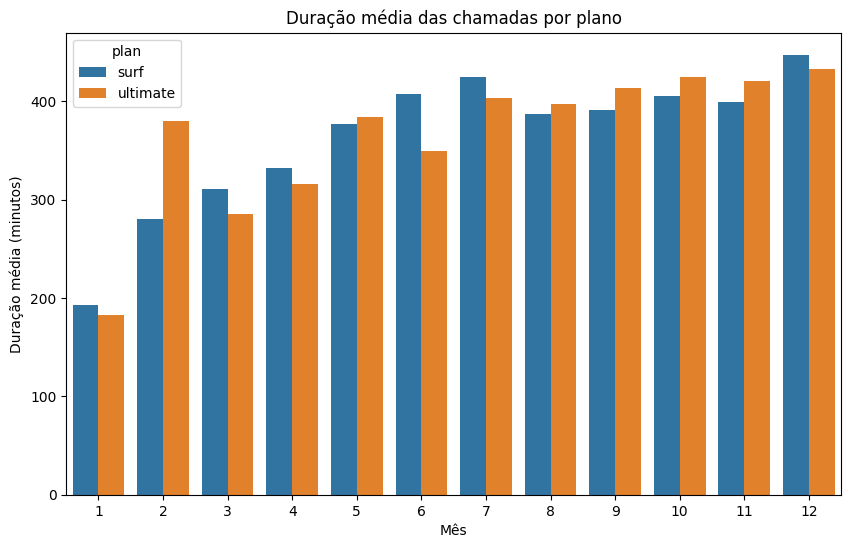

In [246]:
import seaborn as sns

# Calculamos a média por plano e mês
# Calculate average per plan and month

avg_calls = monthly_usage.groupby(['month', 'plan'])['duration'].mean().reset_index()


# Criamos gráfico de barras
# Create bar chart

plt.figure(figsize=(10,6))

sns.barplot(
    data=avg_calls,
    x='month',
    y='duration',
    hue='plan'
)

plt.title('Duração média das chamadas por plano')
plt.xlabel('Mês')
plt.ylabel('Duração média (minutos)')

plt.show()

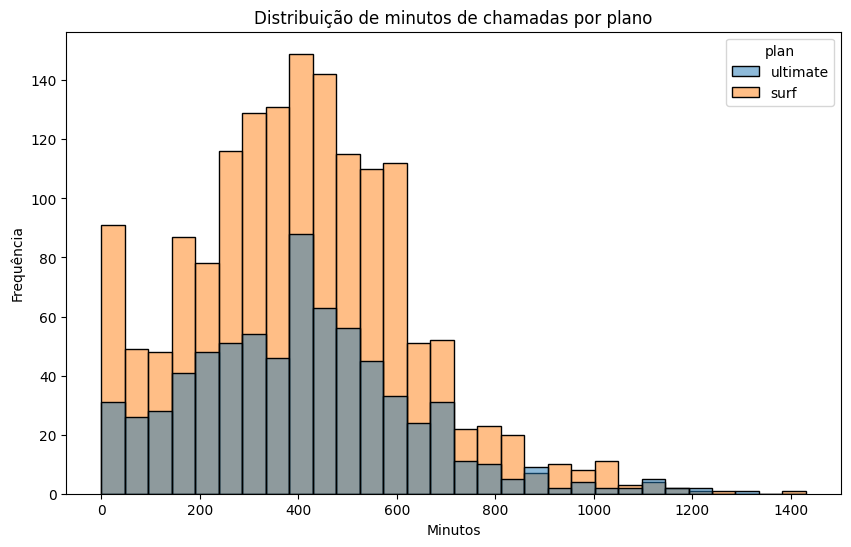

In [247]:
# Comparamos a distribuição de minutos por plano
# Compare distribution of minutes by plan

plt.figure(figsize=(10,6))

sns.histplot(
    data=monthly_usage,
    x='duration',
    hue='plan',
    bins=30,
)

plt.title('Distribuição de minutos de chamadas por plano')
plt.xlabel('Minutos')
plt.ylabel('Frequência')

plt.show()

In [248]:
# Calculamos a média e a variância da duração das chamadas por plano
# We calculate the mean and variance of call duration per plan

stats_calls = monthly_usage.groupby('plan')['duration'].agg(['mean', 'var'])

# Exibimos o resultado
# Display the result

print(stats_calls)

                mean           var
plan                              
surf      404.762390  49135.104891
ultimate  406.193083  51640.971402


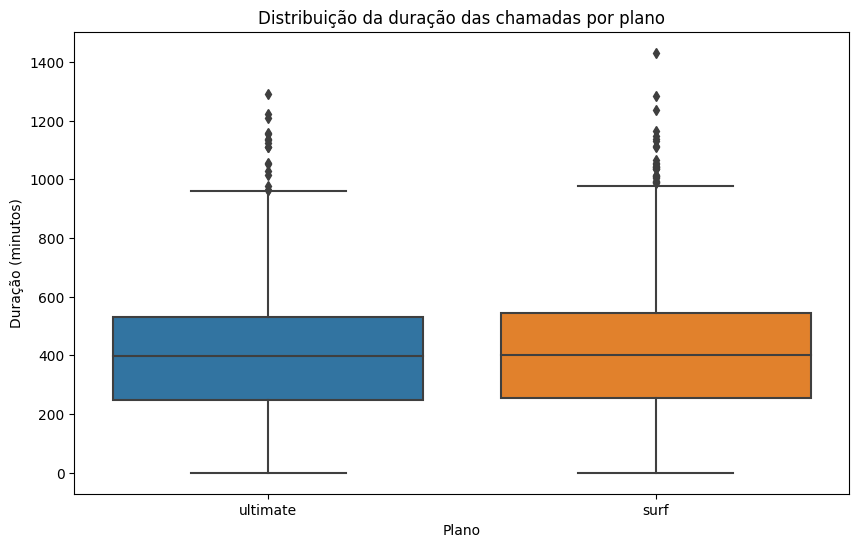

In [249]:
# Criamos um boxplot para visualizar a distribuição da duração das chamadas por plano
# We create a boxplot to visualize the distribution of call duration per plan
plt.figure(figsize=(10,6))

sns.boxplot(
    data=monthly_usage,
    x='plan',
    y='duration'
)

plt.title('Distribuição da duração das chamadas por plano')
plt.xlabel('Plano')
plt.ylabel('Duração (minutos)')

plt.show()

Os usuários dos dois planos apresentam comportamentos semelhantes na duração das chamadas. O plano surf tem uma mediana ligeiramente maior e maior variabilidade. Ambos os planos possuem outliers, indicando usuários com uso mais elevado.

Users of both plans show similar call duration patterns. The surf plan has a slightly higher median and greater variability. Both plans contain outliers, indicating higher-usage users.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Excelente trabalho!
    
Todas as visualizações solicitadas para as chamadas estão presentes e acompanhadas da conclusão sobre o comportamento ilustrado!
    
Muito bom!
</div>


### Mensagens

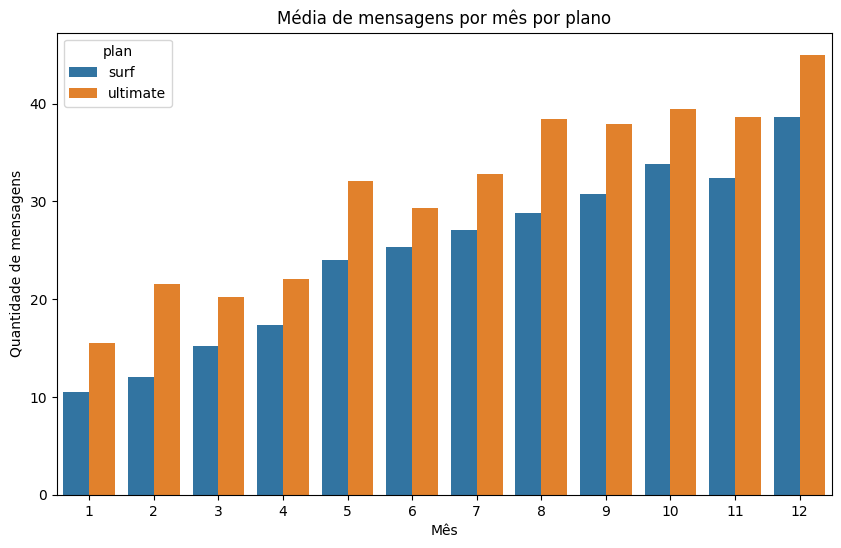

In [250]:
# Calcula a média de mensagens por mês e por plano
# Calculates average messages per month per plan

messages_mean = monthly_usage.groupby(['month', 'plan'])['message_count'].mean().reset_index()

# Cria gráfico de barras
# Creates bar plot

plt.figure(figsize=(10,6))

sns.barplot(
    data=messages_mean,
    x='month',
    y='message_count',
    hue='plan'
)

plt.title('Média de mensagens por mês por plano')
plt.xlabel('Mês')
plt.ylabel('Quantidade de mensagens')

plt.show()

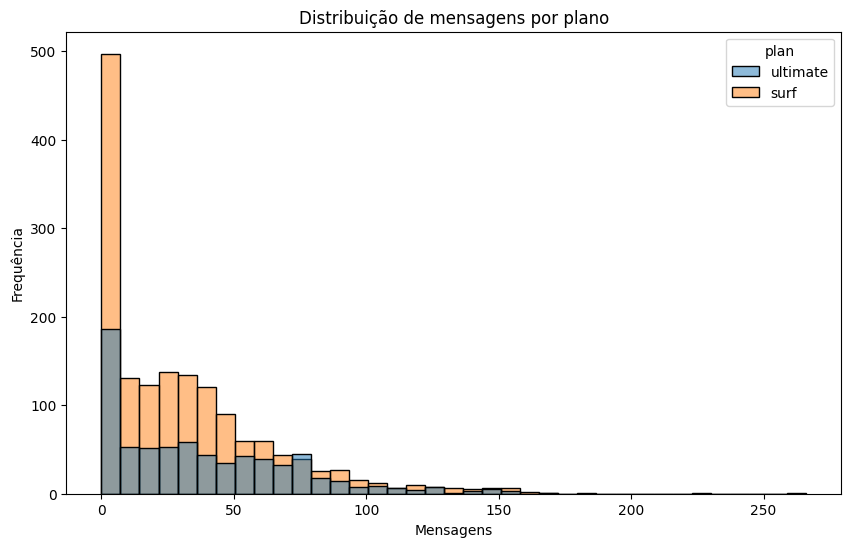

In [251]:
# Histograma da quantidade de mensagens
# Histogram of message usage

plt.figure(figsize=(10,6))

sns.histplot(
    data=monthly_usage,
    x='message_count',
    hue='plan',
)

plt.title('Distribuição de mensagens por plano')
plt.xlabel('Mensagens')
plt.ylabel('Frequência')

plt.show()


In [252]:
# Calcula média e variância das mensagens por plano
# Calculates mean and variance per plan

messages_stats = monthly_usage.groupby('plan')['message_count'].agg(['mean', 'var'])

print(messages_stats)

               mean          var
plan                            
surf      31.159568  1126.724522
ultimate  37.551389  1208.756744


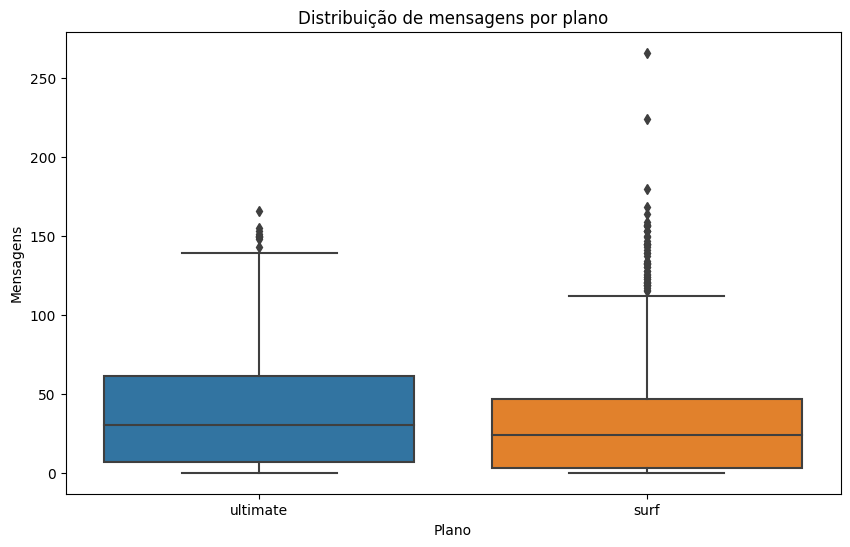

In [253]:
# Boxplot para visualizar distribuição
# Boxplot to visualize distribution of message usage by plan

plt.figure(figsize=(10,6))

sns.boxplot(
    data=monthly_usage,
    x='plan',
    y='message_count'
)

plt.title('Distribuição de mensagens por plano')
plt.xlabel('Plano')
plt.ylabel('Mensagens')

plt.show()

Os usuários dos dois planos apresentam comportamentos semelhantes no envio de mensagens. O plano surf tende a ter uma média ligeiramente maior e maior variabilidade. Ambos os planos possuem outliers, indicando usuários com uso mais elevado.

Users of both plans show similar messaging behavior. The surf plan tends to have a slightly higher average and greater variability. Both plans contain outliers, indicating higher-usage users.

### Internet

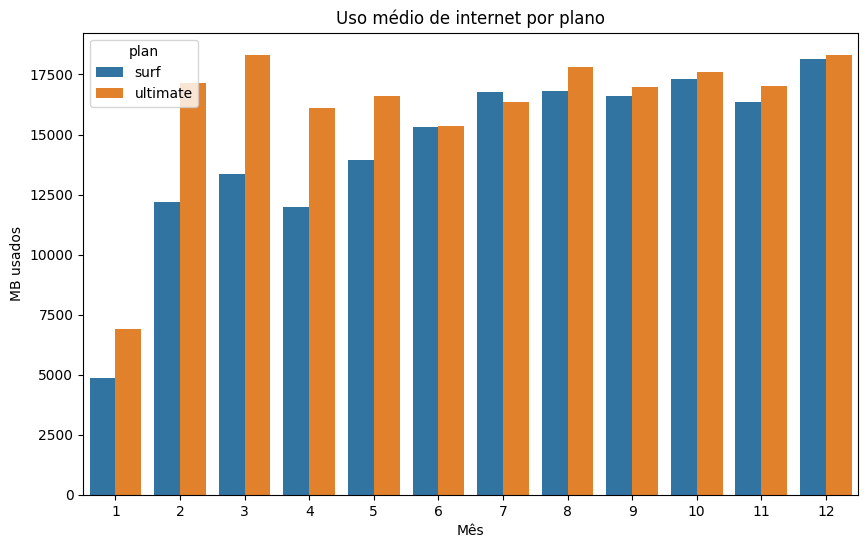

In [254]:
# Calcula a média de uso de internet por mês e por plano
# Calculates average internet usage per month per plan

internet_mean = monthly_usage.groupby(['month', 'plan'])['mb_used'].mean().reset_index()

# Gráfico de barras
# Bar plot

plt.figure(figsize=(10,6))

sns.barplot(
    data=internet_mean,
    x='month',
    y='mb_used',
    hue='plan'
)

plt.title('Uso médio de internet por plano')
plt.xlabel('Mês')
plt.ylabel('MB usados')

plt.show()

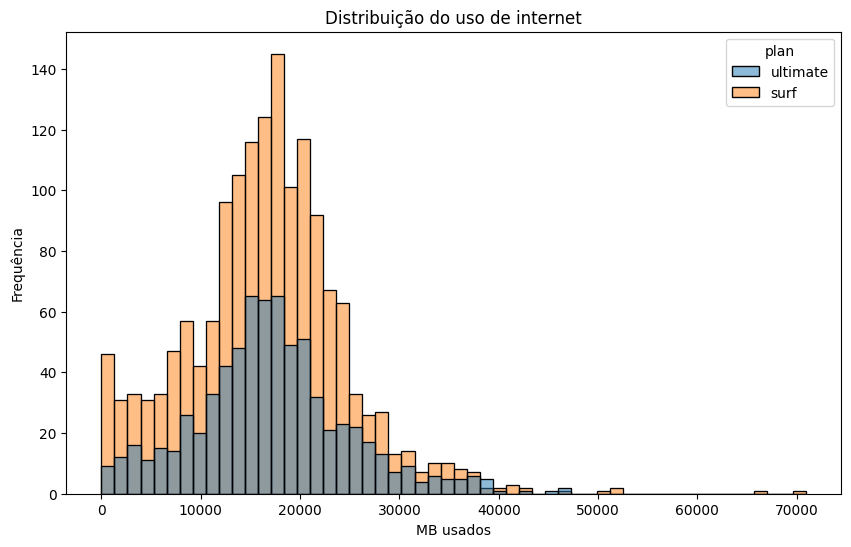

In [255]:
# Distribuição do uso de internet
# Distribution of internet usage by plan

plt.figure(figsize=(10,6))

sns.histplot(
    data=monthly_usage,
    x='mb_used',
    hue='plan'
)

plt.title('Distribuição do uso de internet')
plt.xlabel('MB usados')
plt.ylabel('Frequência')

plt.show()

In [256]:
# Média e variância do uso de internet por plano
# Mean and variance of internet usage per plan

internet_stats = monthly_usage.groupby('plan')['mb_used'].agg(['mean', 'var'])

print(internet_stats)

                  mean           var
plan                                
surf      16558.283490  6.421640e+07
ultimate  17214.699694  6.165229e+07


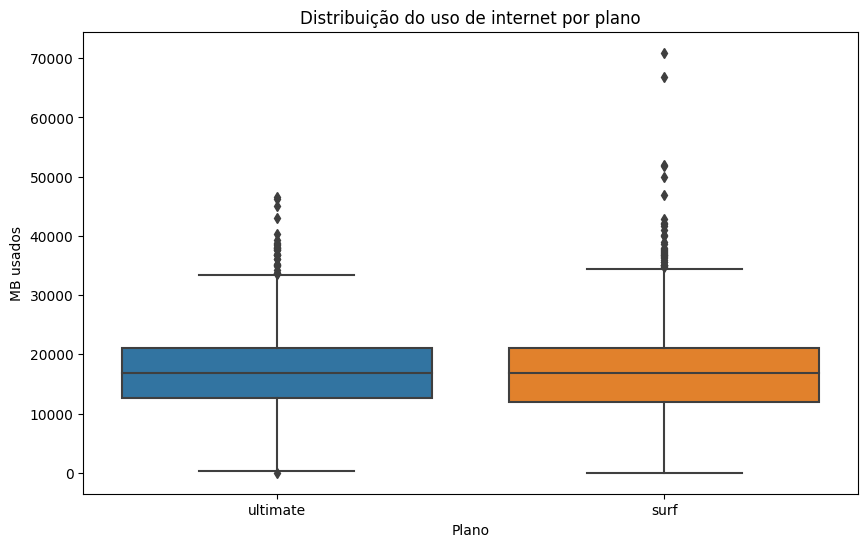

In [257]:
# Boxplot do uso de internet
# Boxplot of internet usage

plt.figure(figsize=(10,6))

sns.boxplot(
    data=monthly_usage,
    x='plan',
    y='mb_used'
)

plt.title('Distribuição do uso de internet por plano')
plt.xlabel('Plano')
plt.ylabel('MB usados')

plt.show()

Os usuários dos dois planos apresentam comportamentos semelhantes no uso de internet. O plano surf tende a apresentar uma média ligeiramente maior e maior variabilidade. Ambos os planos possuem outliers, indicando usuários com consumo elevado.

Users of both plans show similar internet usage patterns. The surf plan tends to have a slightly higher average and greater variability. Both plans contain outliers, indicating high-usage users.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Mensagens e internet tiveram o seu comportamento investigado conforme solicitado na lição, com gráficos e conclusão apresentados.
</div>


## Receita

In [258]:
# Calcula a média e a variância da receita por plano
# Calculates the mean and variance of revenue per plan

revenue_stats = monthly_usage.groupby('plan')['monthly_revenue'].agg(['mean', 'var'])


print(revenue_stats)

               mean          var
plan                            
surf      57.293784  2887.544971
ultimate  72.116080   115.968081


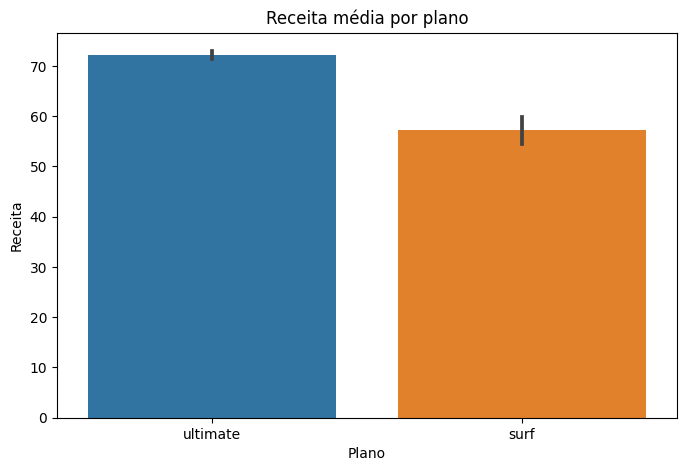

In [259]:
# Cria um gráfico de barras para comparar a receita média entre os planos
# Creates a bar plot to compare average revenue between plans

plt.figure(figsize=(8,5))

sns.barplot(
    data=monthly_usage,
    x='plan',
    y='monthly_revenue'
)

plt.title('Receita média por plano')
plt.xlabel('Plano')
plt.ylabel('Receita')

plt.show()

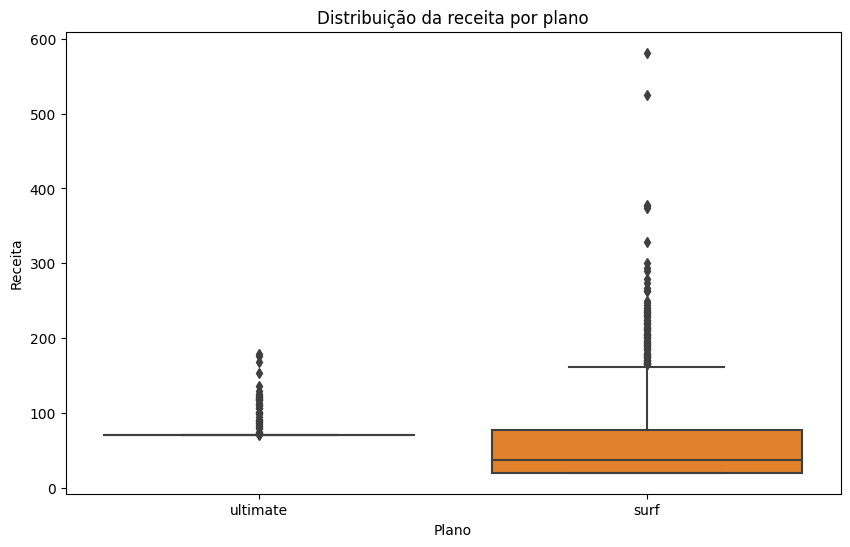

In [260]:
# Boxplot da receita
# Revenue boxplot

plt.figure(figsize=(10,6))

sns.boxplot(
    data=monthly_usage,
    x='plan',
    y='monthly_revenue'
)

plt.title('Distribuição da receita por plano')
plt.xlabel('Plano')
plt.ylabel('Receita')

plt.show()

A receita do plano ultimate é mais estável e consistentemente mais alta devido à mensalidade fixa. Já o plano surf apresenta maior variabilidade, com muitos outliers, indicando que alguns usuários geram receitas muito altas ao exceder os limites do plano.

Revenue from the ultimate plan is more stable and consistently higher due to its fixed monthly fee. In contrast, the surf plan shows greater variability with many outliers, indicating that some users generate high revenue by exceeding plan limits.


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Receita foi investigada por meio de gráficos e conclusões adequadas.

</div>

## Teste hipóteses estatísticas

A receita média dos planos Ultimate e Surf é diferente?

Is the average revenue of Ultimate and Surf plan users different?

Hipóteses:

H0 (hipótese nula):
A receita média dos usuários dos planos Ultimate e Surf é igual.

H1 (hipótese alternativa):
A receita média dos usuários dos planos Ultimate e Surf é diferente.

Vamos usar alpha = 0.05


Null hypothesis (H0):
The average revenue of users in the Ultimate and Surf plans is equal.

Alternative hypothesis (H1):
The average revenue of users in the Ultimate and Surf plans is different.

Significance level:
We use a significance level of 0.05.

In [261]:
# Separamos a receita de cada plano
# Separate revenue for each plan

ultimate_revenue = monthly_usage[monthly_usage['plan'] == 'ultimate']['monthly_revenue']
surf_revenue = monthly_usage[monthly_usage['plan'] == 'surf']['monthly_revenue']

# Definimos o nível de significância
# Define significance level

alpha = 0.05

# Realizamos o teste t para duas amostras independentes
# Perform t-test for two independent samples

results = stats.ttest_ind(ultimate_revenue, surf_revenue, equal_var=False)

print("p-value:", results.pvalue)

# Verificamos se rejeitamos a hipótese nula
# Check whether we reject the null hypothesis

if results.pvalue < alpha:
    print("Rejeitamos a hipótese nula")
else:
    print("Não rejeitamos a hipótese nula")

p-value: 4.881852673479799e-25
Rejeitamos a hipótese nula


Se o p-value for menor que 0.05, rejeitamos a hipótese nula.
Isso significa que a receita média dos planos é estatisticamente diferente.

If the p-value is less than 0.05, we reject the null hypothesis.
This means that the average revenue of the plans is statistically different.

Usuários da região NY-NJ gastam diferente?

Do users from the NY-NJ region generate different average revenue compared to users from other regions?

Hipóteses:

H0:
A receita média dos usuários da região NY-NJ é igual às demais regiões.

H1:
A receita média dos usuários da região NY-NJ é diferente das demais regiões.

Vamos usar alpha = 0.05


Hypothesis (H0):
The average revenue of users in the NY-NJ region is equal to that of users from other regions.

Alternative hypothesis (H1):
The average revenue of users in the NY-NJ region is different from that of users from other regions.

Significance level:
We use a significance level of 0.05.

In [262]:
# Juntamos monthly_usage com users_df para ter a coluna city
# Merge monthly_usage with users_df to get city column

usage_with_city = monthly_usage.merge(users_df[['user_id', 'city']], on='user_id', how='left')


# Filtramos usuários da região NY-NJ
# Filter NY-NJ users

ny_nj = usage_with_city[usage_with_city['city'] == 'New York-Newark-Jersey City, NY-NJ-PA MSA']['monthly_revenue']


# Filtramos os demais usuários
# Filter other users

other_regions = usage_with_city[usage_with_city['city'] != 'New York-Newark-Jersey City, NY-NJ-PA MSA']['monthly_revenue']

alpha = 0.05

results = stats.ttest_ind(ny_nj, other_regions, equal_var=False)

print("p-value:", results.pvalue)

if results.pvalue < alpha:
    print("Rejeitamos a hipótese nula")
else:
    print("Não rejeitamos a hipótese nula")

p-value: 0.01860947297497194
Rejeitamos a hipótese nula


Se o p-value for menor que 0.05, concluímos que a receita média dos usuários da região NY-NJ é diferente das demais regiões. Caso contrário, não rejeitamos a hipótese nula.

If the p-value is less than 0.05, we conclude that the average revenue of NY-NJ users is different from other regions. Otherwise, we fail to reject the null hypothesis.


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Os testes foram formulados, implementados e analisados corretamente. Muito bom!
</div>


## Conclusão geral
Neste projeto, foram analisados dados de usuários, chamadas, mensagens, uso de internet e planos com o objetivo de comparar o comportamento dos clientes dos planos Surf e Ultimate.

Durante a etapa de pré-processamento, as colunas de data foram convertidas para o formato datetime, valores ausentes e duplicados foram verificados, e os dados foram integrados por meio de operações de merge entre os diferentes datasets. Para possibilitar a análise temporal, foi criada uma coluna de mês e os dados foram agregados mensalmente por usuário.

Assumiu-se que valores ausentes após a agregação representavam ausência de uso do serviço e, portanto, foram substituídos por zero. A receita mensal foi calculada considerando a mensalidade fixa de cada plano e os custos adicionais decorrentes do uso acima dos limites incluídos.

A análise exploratória indicou que os usuários dos dois planos apresentam comportamentos semelhantes em termos de chamadas, mensagens e uso de internet. No entanto, o plano Surf apresentou maior variabilidade e maior presença de outliers, sugerindo que parte dos usuários excede os limites com mais frequência. Em relação à receita, o plano Ultimate apresentou valores médios mais altos e maior estabilidade, enquanto o plano Surf demonstrou maior dispersão devido à cobrança de excedentes.

Os testes de hipóteses confirmaram que há diferença estatisticamente significativa entre as receitas médias dos planos. A análise por região também foi conduzida para verificar possíveis diferenças entre usuários da área NY-NJ e das demais regiões.

Em conclusão, o plano Ultimate se mostra mais estável e previsível em termos de receita, enquanto o plano Surf apresenta maior variabilidade de uso e faturamento. Os resultados reforçam a importância do tratamento adequado dos dados e da aplicação de métodos estatísticos para a tomada de decisões baseadas em dados.

In this project, data on users, calls, messages, internet usage, and plans were analyzed to compare the behavior of customers subscribed to the Surf and Ultimate plans.

During the data preprocessing stage, date columns were converted to datetime format, missing values and duplicates were checked, and the datasets were integrated through merge operations. To enable time-based analysis, a month column was created and the data was aggregated on a monthly basis per user.

It was assumed that missing values after aggregation represented no usage of the corresponding service and were therefore replaced with zero. Monthly revenue was calculated based on the fixed subscription fee of each plan and additional charges for usage exceeding the included limits.

The exploratory analysis showed that users of both plans exhibit similar behavior in terms of calls, messages, and internet usage. However, the Surf plan demonstrated greater variability and a higher number of outliers, indicating that some users exceed their plan limits more frequently. In terms of revenue, the Ultimate plan showed higher average values and greater stability, while the Surf plan exhibited more dispersion due to overage charges.

The hypothesis tests confirmed that there is a statistically significant difference between the average revenues of the two plans. An additional analysis by region was conducted to assess whether users from the NY-NJ area differ from users in other regions.

In conclusion, the Ultimate plan appears to be more stable and predictable in terms of revenue, while the Surf plan shows greater variability in both usage and billing. These results highlight the importance of proper data preprocessing and statistical analysis for data-driven decision-making.